# Random Forest vs. Linear Algebra: Which One Actually Conserves Energy?

A harmonic oscillator's total energy $E=\tfrac12 kx^2+\tfrac12 mv^2$ is
EXACTLY conserved along any real trajectory. The **linear-algebra**
propagator (eigendecomposition of the state matrix $\dot{\vec z}=A\vec z$,
the same method used for the photosynthesis rate-matrix and Schrodinger-PDE
notebooks earlier this session) conserves it exactly, by construction --
energy conservation is baked into the structure of the equations, not an
extra constraint.

A **Decision Tree** or **Random Forest** regressor, trained to predict
energy from $(x,v)$ samples, has no idea any such law exists. It just fits
a function to data. This notebook trains both, then feeds them a held-out
trajectory where the TRUE energy is dead flat, and watches what each model
actually predicts -- a concrete demonstration of why "the model fits the
training data well" is not the same claim as "the model respects the
physics," and why physics-informed ML (the GS-verifier-style modules built
earlier this session) is a real, separate idea from generic ML.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

plt.rcParams["figure.dpi"] = 110
rng = np.random.default_rng(0)


## 1. The linear-algebra ground truth: an exact, energy-conserving propagator

$\dot{\vec z} = A\vec z$ with $\vec z=(x,v)$ and
$A=\begin{pmatrix}0&1\\-k/m&0\end{pmatrix}$. Solved via eigendecomposition
(complex eigenvalues $\pm i\omega$ give the oscillation) -- exact at any
time step, no numerical drift.


In [2]:
def shm_propagate(x0, v0, k, m, t):
    A = np.array([[0.0, 1.0], [-k / m, 0.0]])
    eigvals, eigvecs = np.linalg.eig(A)
    z0 = np.array([x0, v0], dtype=complex)
    coeffs = np.linalg.solve(eigvecs, z0)
    t = np.asarray(t, dtype=float)
    modes = np.exp(np.outer(t, eigvals))
    z_t = np.einsum("ni,ti,i->tn", eigvecs, modes, coeffs)
    return z_t.real   # (T, 2): columns are x(t), v(t)

def energy(x, v, k, m):
    return 0.5 * k * x**2 + 0.5 * m * v**2

k_val, m_val = 4.0, 1.0
t_grid = np.linspace(0, 20, 400)
traj = shm_propagate(x0=1.0, v0=0.0, k=k_val, m=m_val, t=t_grid)
E_exact = energy(traj[:, 0], traj[:, 1], k_val, m_val)

print(f"energy range along the EXACT trajectory: [{E_exact.min():.10f}, {E_exact.max():.10f}]")
print(f"(should be a single number to ~machine precision -- conserved exactly)")


energy range along the EXACT trajectory: [2.0000000000, 2.0000000000]
(should be a single number to ~machine precision -- conserved exactly)


## 2. Generate training data and fit a Decision Tree + Random Forest

Sample many random $(x,v)$ states across a range of energies, label each
with its TRUE energy, and train both models as ordinary regressors -- they
never see the equations of motion, only $(x,v)\to E$ pairs.


In [3]:
n_samples = 4000
x_train = rng.uniform(-2, 2, n_samples)
v_train = rng.uniform(-3, 3, n_samples)
E_train = energy(x_train, v_train, k_val, m_val)
X_train = np.column_stack([x_train, v_train])

tree_model = DecisionTreeRegressor(max_depth=6, random_state=0).fit(X_train, E_train)
forest_model = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=0).fit(X_train, E_train)

# sanity check: both models fit the TRAINING distribution well
print("training R^2, decision tree:  ", tree_model.score(X_train, E_train))
print("training R^2, random forest: ", forest_model.score(X_train, E_train))


training R^2, decision tree:   0.9376933924411053
training R^2, random forest:  0.9874906745243708


## 3. Feed both models a held-out trajectory where the TRUE energy is flat

This is the real test: not "does it fit training data" but "does it
respect the actual physical law along a trajectory it wasn't trained on
directly" (even though every individual point lies inside the training
range).


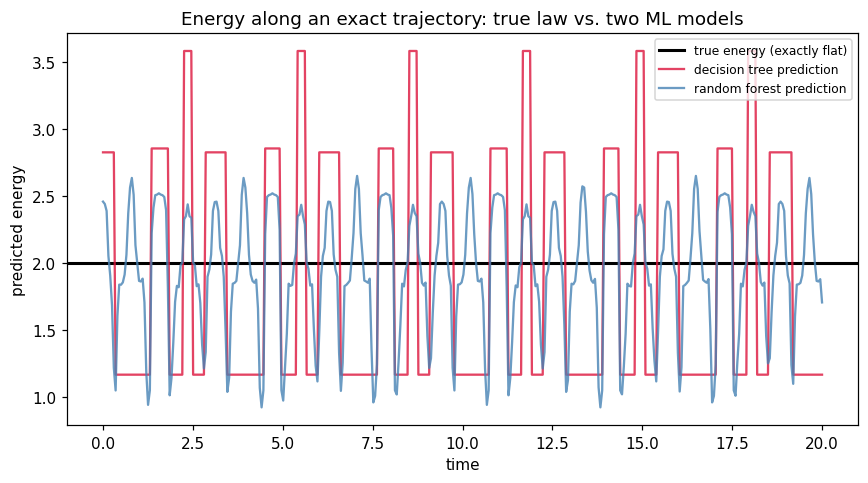

true energy std along trajectory:          5.78e-16  (should be ~0)
decision tree prediction std along traj:    0.9108
random forest prediction std along traj:    0.4619


In [4]:
E_pred_tree = tree_model.predict(traj)
E_pred_forest = forest_model.predict(traj)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.axhline(E_exact[0], color="black", lw=2, label="true energy (exactly flat)")
ax.plot(t_grid, E_pred_tree, color="crimson", alpha=0.8, label="decision tree prediction")
ax.plot(t_grid, E_pred_forest, color="steelblue", alpha=0.8, label="random forest prediction")
ax.set_xlabel("time")
ax.set_ylabel("predicted energy")
ax.set_title("Energy along an exact trajectory: true law vs. two ML models")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"true energy std along trajectory:          {np.std(E_exact):.2e}  (should be ~0)")
print(f"decision tree prediction std along traj:    {np.std(E_pred_tree):.4f}")
print(f"random forest prediction std along traj:    {np.std(E_pred_forest):.4f}")


## 4. Why: tree ensembles are piecewise-constant, $x^2+v^2$ is smooth and curved

Decision trees (and forests of them) partition the input space into
axis-aligned boxes and predict a constant in each box. The true energy
surface $E(x,v)=\tfrac12 kx^2+\tfrac12 mv^2$ is a smooth paraboloid -- a
step-function approximation to a smooth curved surface necessarily wobbles
as $(x,v)$ traces a circle/ellipse of constant true energy, EVEN with
abundant, noise-free training data covering that exact region. This isn't a
training-data problem; it's a structural mismatch between the model class
and the conservation law.


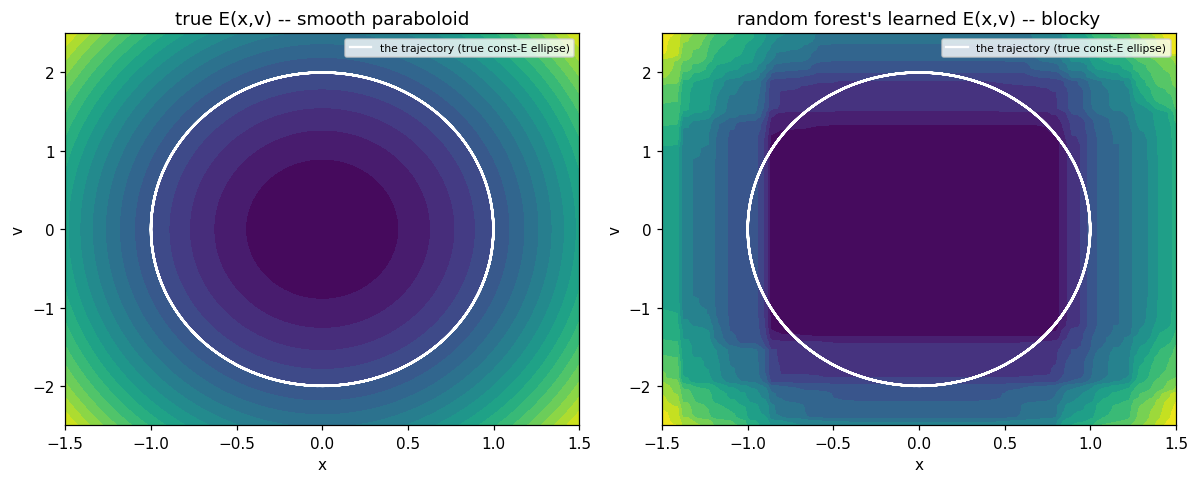

In [5]:
# direct visualization: the learned energy surface vs the true one, restricted
# to the actual energy-conserving ellipse the trajectory traces
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
x_grid_2d, v_grid_2d = np.meshgrid(np.linspace(-1.5, 1.5, 100), np.linspace(-2.5, 2.5, 100))
E_true_surface = energy(x_grid_2d, v_grid_2d, k_val, m_val)
E_forest_surface = forest_model.predict(np.column_stack([x_grid_2d.ravel(), v_grid_2d.ravel()])).reshape(x_grid_2d.shape)

for ax, surface, title in [(axes[0], E_true_surface, "true E(x,v) -- smooth paraboloid"),
                            (axes[1], E_forest_surface, "random forest's learned E(x,v) -- blocky")]:
    cs = ax.contourf(x_grid_2d, v_grid_2d, surface, levels=20, cmap="viridis")
    ax.plot(traj[:, 0], traj[:, 1], color="white", lw=1.5, label="the trajectory (true const-E ellipse)")
    ax.set_title(title)
    ax.set_xlabel("x"); ax.set_ylabel("v")
    ax.legend(fontsize=7)
fig.tight_layout()
plt.show()


## Summary

The linear-algebra propagator conserves $E$ to machine precision because
energy conservation is a structural consequence of $A$'s eigenstructure --
not a constraint that was added, just a fact that's already true of the
equations. A Random Forest fit to abundant, noise-free $(x,v)\to E$ data
gets every individual training point right, yet still predicts a visibly
wobbling, non-constant energy along the exact same conserved trajectory --
because nothing in a tree ensemble's structure knows $x^2+v^2$ should be
constant on a circle. The fix in real physics-informed ML (as in the GS-
verifier and rate-matrix modules built earlier this session) is to bake the
known structure into the model -- feature-engineer $x^2,v^2$ directly, or
use the literal linear-algebra solution -- rather than hope a generic
regressor discovers a conservation law from data alone.
